# asymptotics — Non-Standard Gauge Sequences

In classical perturbation theory the standard ansatz assumes a power series in $\varepsilon$:

$$x(\varepsilon) = x_0 + \varepsilon\, x_1 + \varepsilon^2\, x_2 + \cdots$$

But many problems require a **different asymptotic scale** — when the solution is not analytic in $\varepsilon$.  The general form is

$$x(\varepsilon) = x_0\,\delta_0(\varepsilon) + x_1\,\delta_1(\varepsilon) + x_2\,\delta_2(\varepsilon) + \cdots$$

where $\{\delta_k(\varepsilon)\}$ is any **asymptotic sequence** satisfying $\delta_{k+1}/\delta_k \to 0$ as $\varepsilon\to 0$.

`asymptotics` supports arbitrary gauge sequences via the `gauge=` keyword on `expand_regular()`.

| `gauge=` value | Sequence generated |
|:--------------|:-------------------|
| `None` (default) | $\{1,\varepsilon,\varepsilon^2,\ldots\}$ |
| `'sqrt(eps)'` | $\{1,\sqrt\varepsilon,\varepsilon,\varepsilon^{3/2},\ldots\}$ — inferred geometrically |
| `'eps**(1/3)'` | $\{1,\varepsilon^{1/3},\varepsilon^{2/3},\varepsilon,\ldots\}$ — inferred geometrically |
| `['1','eps*log(eps)','eps']` | $\{1,\varepsilon\ln\varepsilon,\varepsilon\}$ — explicit list, required for non-geometric sequences |


In [1]:
from asymptotics import AlgebraicEquation, ODE
%config InlineBackend.figure_format = 'svg'

---
## Example 1 — Branch point: $x^2 = \varepsilon$

The equation $x^2 - \varepsilon = 0$ has the exact solution $x = \sqrt{\varepsilon}$.

**Why the standard gauge fails:** substituting $x = x_0 + \varepsilon x_1 + \cdots$ gives

$$O(1):\; x_0^2 = 0 \;\Rightarrow\; x_0 = 0 \qquad O(\varepsilon):\; -1 = 0 \quad \textbf{contradiction!}$$

The solution has a *branch point* at $\varepsilon = 0$ — it is not analytic in $\varepsilon$, only in $\sqrt\varepsilon$.
The correct gauge is $\{\sqrt\varepsilon,\, \varepsilon,\, \varepsilon^{3/2},\ldots\}$.


In [2]:
eq = AlgebraicEquation("x**2 - eps", dependent="x", small_param="eps")

# Standard gauge fails — show the error
try:
    eq.expand_regular(order=2)
except Exception as e:
    print("Standard gauge failed (expected):")
    for line in str(e).strip().splitlines():
        if line.strip():
            print(" ", line.strip())
            break

Standard gauge failed (expected):
  Could not solve the order-1 equation for x_1:


In [3]:
# Correct: explicit gauge starting at sqrt(eps)
sol = eq.expand_regular(order=2, gauge=["sqrt(eps)", "eps", "eps**(3/2)"])
sol.show()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

{'eps': array([0.001     , 0.00731646, 0.01363291, 0.01994937, 0.02626582,
        0.03258228, 0.03889873, 0.04521519, 0.05153165, 0.0578481 ,
        0.06416456, 0.07048101, 0.07679747, 0.08311392, 0.08943038,
        0.09574684, 0.10206329, 0.10837975, 0.1146962 , 0.12101266,
        0.12732911, 0.13364557, 0.13996203, 0.14627848, 0.15259494,
        0.15891139, 0.16522785, 0.1715443 , 0.17786076, 0.18417722,
        0.19049367, 0.19681013, 0.20312658, 0.20944304, 0.21575949,
        0.22207595, 0.22839241, 0.23470886, 0.24102532, 0.24734177,
        0.25365823, 0.25997468, 0.26629114, 0.27260759, 0.27892405,
        0.28524051, 0.29155696, 0.29787342, 0.30418987, 0.31050633,
        0.31682278, 0.32313924, 0.3294557 , 0.33577215, 0.34208861,
        0.34840506, 0.35472152, 0.36103797, 0.36735443, 0.37367089,
        0.37998734, 0.3863038 , 0.39262025, 0.39893671, 0.40525316,
        0.41156962, 0.41788608, 0.42420253, 0.43051899, 0.43683544,
        0.4431519 , 0.44946835, 0.4557848

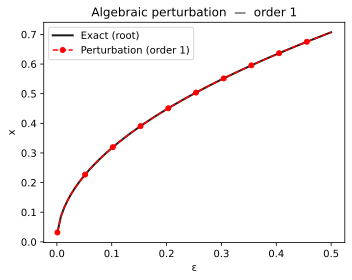

In [4]:
eps_vals = [0.001 + i*(0.5 - 0.001)/79 for i in range(80)]
sol.compare_numeric(eps=eps_vals)

---
## Example 2 — Mixed gauge: $x^2 + \sqrt\varepsilon\, x - 1 = 0$

The equation $x^2 + \sqrt\varepsilon\, x - 1 = 0$ has an exact solution involving $\sqrt\varepsilon$:

$$x = \frac{-\sqrt\varepsilon + \sqrt{\varepsilon + 4}}{2} = 1 - \frac{\sqrt\varepsilon}{2} + \frac{\varepsilon}{8} - \frac{\varepsilon^{3/2}}{16} + \cdots$$

**Standard gauge fails** again: the $O(1)$ equation gives $x_0 = 1$, but the $O(\varepsilon)$ equation has no $x_1$ in it (the perturbation is $O(\sqrt\varepsilon)$, not $O(\varepsilon)$), producing a contradiction.

The correct gauge is $\{1, \sqrt\varepsilon, \varepsilon, \varepsilon^{3/2}, \ldots\}$, captured by `gauge='sqrt(eps)'`.


In [5]:
eq = AlgebraicEquation("x**2 + sqrt(eps)*x - 1", dependent="x", small_param="eps")

# Standard gauge fails
try:
    eq.expand_regular(order=3)
except Exception as e:
    print("Standard gauge failed (expected):")
    for line in str(e).strip().splitlines():
        if line.strip():
            print(" ", line.strip())
            break

Standard gauge failed (expected):
  Could not solve the order-1 equation for x_1:


In [6]:
# String pattern 'sqrt(eps)' infers {1, sqrt(eps), eps, eps^(3/2), ...}
sol = eq.expand_regular(order=3, gauge="sqrt(eps)")
sol.show()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

{'eps': array([0.001     , 0.01111392, 0.02122785, 0.03134177, 0.0414557 ,
        0.05156962, 0.06168354, 0.07179747, 0.08191139, 0.09202532,
        0.10213924, 0.11225316, 0.12236709, 0.13248101, 0.14259494,
        0.15270886, 0.16282278, 0.17293671, 0.18305063, 0.19316456,
        0.20327848, 0.21339241, 0.22350633, 0.23362025, 0.24373418,
        0.2538481 , 0.26396203, 0.27407595, 0.28418987, 0.2943038 ,
        0.30441772, 0.31453165, 0.32464557, 0.33475949, 0.34487342,
        0.35498734, 0.36510127, 0.37521519, 0.38532911, 0.39544304,
        0.40555696, 0.41567089, 0.42578481, 0.43589873, 0.44601266,
        0.45612658, 0.46624051, 0.47635443, 0.48646835, 0.49658228,
        0.5066962 , 0.51681013, 0.52692405, 0.53703797, 0.5471519 ,
        0.55726582, 0.56737975, 0.57749367, 0.58760759, 0.59772152,
        0.60783544, 0.61794937, 0.62806329, 0.63817722, 0.64829114,
        0.65840506, 0.66851899, 0.67863291, 0.68874684, 0.69886076,
        0.70897468, 0.71908861, 0.7292025

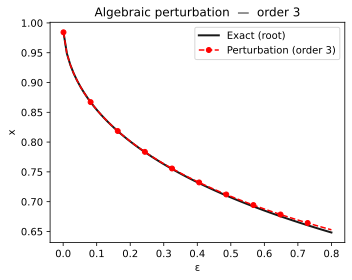

In [7]:
eps_vals = [0.001 + i*(0.8 - 0.001)/79 for i in range(80)]
sol.compare_numeric(eps=eps_vals)

---
## Example 3 — Logarithmic gauge: $x(1 + \varepsilon\ln\varepsilon) = 1$

Logarithmic terms $\varepsilon\ln\varepsilon$ arise naturally in 2D Stokes flow past a cylinder, and in eigenvalue problems near singular points.  This gauge is **not** geometric — `eps*log(eps)` grows slower than any power of `eps`, so the sequence $\{1, \varepsilon\ln\varepsilon, \varepsilon\}$ cannot be generated from a string pattern.  You must supply an **explicit list**.

The equation $x + \varepsilon\ln(\varepsilon)\cdot x - 1 = 0$ has exact solution $x = 1/(1 + \varepsilon\ln\varepsilon)$.

**Standard gauge:** gives $x \approx 1$ — the logarithmic correction is completely invisible.

**Log gauge** $\{1,\, \varepsilon\ln\varepsilon,\, \varepsilon\}$: correctly gives $x \approx 1 - \varepsilon\ln\varepsilon$.


In [8]:
eq = AlgebraicEquation("x + eps*log(eps)*x - 1", dependent="x", small_param="eps")

# Standard gauge: eps*log(eps) -> -inf as eps->0, so series expansion breaks
try:
    eq.expand_regular(order=2)
except Exception as e:
    print("Standard gauge failed (expected):")
    for line in str(e).strip().splitlines():
        if line.strip():
            print(" ", line.strip())
            break

Standard gauge failed (expected):
  Could not solve the order-1 equation for x_1:


In [9]:
# Explicit log gauge — must be a list, not a string pattern
sol = eq.expand_regular(order=2, gauge=["1", "eps*log(eps)", "eps"])
sol.show()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

{'eps': array([0.005     , 0.00620253, 0.00740506, 0.00860759, 0.00981013,
        0.01101266, 0.01221519, 0.01341772, 0.01462025, 0.01582278,
        0.01702532, 0.01822785, 0.01943038, 0.02063291, 0.02183544,
        0.02303797, 0.02424051, 0.02544304, 0.02664557, 0.0278481 ,
        0.02905063, 0.03025316, 0.0314557 , 0.03265823, 0.03386076,
        0.03506329, 0.03626582, 0.03746835, 0.03867089, 0.03987342,
        0.04107595, 0.04227848, 0.04348101, 0.04468354, 0.04588608,
        0.04708861, 0.04829114, 0.04949367, 0.0506962 , 0.05189873,
        0.05310127, 0.0543038 , 0.05550633, 0.05670886, 0.05791139,
        0.05911392, 0.06031646, 0.06151899, 0.06272152, 0.06392405,
        0.06512658, 0.06632911, 0.06753165, 0.06873418, 0.06993671,
        0.07113924, 0.07234177, 0.0735443 , 0.07474684, 0.07594937,
        0.0771519 , 0.07835443, 0.07955696, 0.08075949, 0.08196203,
        0.08316456, 0.08436709, 0.08556962, 0.08677215, 0.08797468,
        0.08917722, 0.09037975, 0.0915822

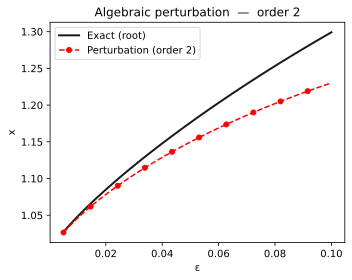

In [10]:
eps_vals = [0.005 + i*(0.1 - 0.005)/79 for i in range(80)]
sol.compare_numeric(eps=eps_vals)

---
## Example 4 — ODE with $\sqrt\varepsilon$ perturbation

Gauge sequences apply equally to ODEs.  Consider

$$u'' + u + \sqrt\varepsilon\, u^2 = 0, \quad u(0) = 1,\quad u'(0) = 0$$

The perturbation is $O(\sqrt\varepsilon)$, so the natural ansatz is

$$u = u_0(t) + \sqrt\varepsilon\; u_1(t) + \varepsilon\; u_2(t) + \cdots$$

The standard gauge would fail: the $O(\varepsilon)$ equation contains no $u_1$ since the nonlinear term is $O(\sqrt\varepsilon)$, leading to $0 = 0$ at $O(\varepsilon)$ while the actual $O(\sqrt\varepsilon)$ correction goes unresolved.


In [11]:
eq = ODE("u'' + u + eps**(1/2)*u**2", small_param="eps",
         conditions=["u(0)=1", "u'(0)=0"])

sol = eq.expand_regular(order=2, gauge="sqrt(eps)")
sol.show()

  ℹ️  dependent = 'u' (inferred from conditions), independent = 't' (inferred from equation)
     To override: ODE(..., dependent='u', independent='t')


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

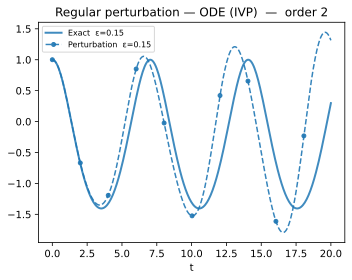

In [13]:
result = sol.compare_numeric(eps=0.15, plot_range=[0, 20])

---
## Summary

In every example above, the **standard gauge fails** — either with an outright contradiction or by producing a flat `x ≈ constant` that misses the dominant correction.  A non-standard gauge is not a convenience; it is a **necessity** when the solution has a branch point or logarithmic singularity in $\varepsilon$.

| Equation feature | Standard gauge result | Correct gauge |
|:----------------|:---------------------|:--------------|
| $x^n = \varepsilon$ (branch point) | Contradiction at $O(\varepsilon)$ | `['eps**(1/n)', ...]` explicit |
| $f + \sqrt\varepsilon\,g = 0$ | Contradiction at $O(\varepsilon)$ | `gauge='sqrt(eps)'` |
| $\varepsilon\ln\varepsilon$ term | Correction invisible | `['1','eps*log(eps)','eps']` explicit |

**Format rule:** use a **string** for geometric sequences (ratio is constant), use an **explicit list** for non-geometric sequences (logarithmic).  The list must have exactly `order + 1` terms.
